# Qualidade dos Dados de Inventário

Levantamento de completude dos dados de inventário para os plots com cobertura LiDAR.
Para cada árvore, verificamos quais campos estão disponíveis em função dos **3 modelos de biomassa** planejados:

| Modelo | Distinção de espécie | Palmeira vs árvore | Vivo/morto | Campos necessários |
|--------|---------------------|--------------------|------------|--------------------|
| **M1** — simples | ✗ | ✗ | ✗ | DBH |
| **M2** — médio   | ✗ | ✓ | ✓ | DBH + type + dead |
| **M3** — completo| ✓ | ✓ | ✓ | DBH + type + dead + scientific_name |

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

ROOT    = Path("..")
INV_DIR = ROOT / "data/processed/04_inventory"
TEMP_CSV = ROOT / "data/processed/02_intersections/intersections_temporal.csv"

plt.rcParams["figure.dpi"] = 130
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

In [2]:
# Ano LiDAR por site (melhor match temporal)
temp = pd.read_csv(TEMP_CSV)
temp["abs_gap"] = temp["gap_temporal_anos"].abs()
best_yr = (
    temp.sort_values(["abs_gap", "ano_lidar"], ascending=[True, False])
    .groupby("nome_area_inventario")["ano_lidar"]
    .first()
    .astype(int)
    .to_dict()
)

def pick_best_year_col(cols, prefix, lidar_year):
    """From dbh_2013, dbh_2018 etc., picks the one closest to lidar_year.
    Falls back to bare 'dbh' if no year-suffixed columns exist."""
    suffixed = [c for c in cols if c.startswith(f"{prefix}_")]
    if not suffixed:
        return prefix if prefix in cols else None
    years = {c: int(c.split("_")[-1]) for c in suffixed}
    return min(years, key=lambda c: abs(years[c] - lidar_year))

print("Ano LiDAR por site:")
for site, yr in sorted(best_yr.items()):
    print(f"  {site:<50} {yr}")

Ano LiDAR por site:
  ANA_A01_2015_2018_inventory_plots                  2017
  AND_A01_2013_2018_inventory_plots                  2013
  CAU_A01_2014_2018_inventory                        2014
  DUC_A01_2009_2011_inventory_plots                  2008
  DUC_A01_2016_inventory_plots                       2017
  FNA_A01_2013_inventory_plots                       2013
  FN_A01_2015_inventory_plots                        2017
  FST_A01_2013_inventory_plots                       2013
  HUM_A01_2014_inventory_plots                       2013
  JAM_A02_2011_inventory_plots                       2014
  JAM_A02_2013_inventory_plots                       2013
  JAM_A03_2013_inventory_plots                       2013
  PAR_A01_2013_2018_inventory_plots                  2013
  SAN_A01_2014_2016_inventory_plots                  2014
  SAN_A01b_2016_2018_inventory_plots                 2014
  SAN_A02_2014_inventory_plots                       2014
  SFX_A01_2011_inventory_plots                      

In [3]:
# Carrega todos os CSVs e consolida campos de interesse
records = []

for csv in sorted(INV_DIR.glob("*.csv")):
    if csv.name == "README.md":
        continue
    site = csv.stem
    df = pd.read_csv(csv, low_memory=False)
    if df.empty:
        continue

    lidar_yr = best_yr.get(site, 2015)
    cols = df.columns.tolist()

    dbh_col  = pick_best_year_col(cols, "dbh",  lidar_yr)
    htot_col = pick_best_year_col(cols, "htot", lidar_yr)
    dead_col = pick_best_year_col(cols, "dead", lidar_yr)
    type_col = pick_best_year_col(cols, "type", lidar_yr)

    for _, row in df.iterrows():
        records.append({
            "site":            site,
            "plot_id":         str(row.get("plot_id", "")),
            "dbh":             row[dbh_col]  if dbh_col  else np.nan,
            "htot":            row[htot_col] if htot_col else np.nan,
            "type":            row[type_col] if type_col else np.nan,
            "dead":            row[dead_col] if dead_col else np.nan,
            "scientific_name": row.get("scientific_name", np.nan),
            "family_name":     row.get("family_name", np.nan),
            "dbh_col_used":    dbh_col,
            "lidar_year":      lidar_yr,
        })

trees = pd.DataFrame(records)
print(f"Total de árvores carregadas: {len(trees):,}")
print(f"Sites: {trees['site'].nunique()}")

Total de árvores carregadas: 20,597
Sites: 21


In [4]:
# Flags de completude por campo
trees["ok_dbh"]  = trees["dbh"].notna()  & (pd.to_numeric(trees["dbh"], errors="coerce") > 0)
trees["ok_htot"] = trees["htot"].notna() & (pd.to_numeric(trees["htot"], errors="coerce") > 0)
trees["ok_type"] = trees["type"].notna() & (trees["type"].astype(str).str.strip() != "")
trees["ok_dead"] = trees["dead"].notna()
trees["ok_sci"]  = trees["scientific_name"].notna() & (trees["scientific_name"].astype(str).str.strip().str.upper() != "NAN")

# Elegibilidade por modelo
trees["modelo_1"] = trees["ok_dbh"]
trees["modelo_2"] = trees["ok_dbh"] & trees["ok_type"] & trees["ok_dead"]
trees["modelo_3"] = trees["ok_dbh"] & trees["ok_type"] & trees["ok_dead"] & trees["ok_sci"]

print("=== Totais globais ===")
n = len(trees)
for col, label in [
    ("ok_dbh",  "DBH presente"),
    ("ok_htot", "Altura (Htot) presente"),
    ("ok_type", "Tipo (O/P) presente"),
    ("ok_dead", "Status (vivo/morto) presente"),
    ("ok_sci",  "Nome científico presente"),
    ("modelo_1","Elegível — Modelo 1 (só DBH)"),
    ("modelo_2","Elegível — Modelo 2 (DBH+type+dead)"),
    ("modelo_3","Elegível — Modelo 3 (DBH+type+dead+espécie)"),
]:
    cnt = trees[col].sum()
    print(f"  {label:<48} {cnt:>6,}  ({100*cnt/n:.0f}%)")

=== Totais globais ===
  DBH presente                                     17,517  (85%)
  Altura (Htot) presente                            6,251  (30%)
  Tipo (O/P) presente                              20,597  (100%)
  Status (vivo/morto) presente                     18,078  (88%)
  Nome científico presente                         18,604  (90%)
  Elegível — Modelo 1 (só DBH)                     17,517  (85%)
  Elegível — Modelo 2 (DBH+type+dead)              17,517  (85%)
  Elegível — Modelo 3 (DBH+type+dead+espécie)      15,884  (77%)


In [5]:
# Tabela por site
site_summary = (
    trees.groupby("site")
    .agg(
        total=("dbh", "count"),
        dbh=("ok_dbh", "sum"),
        htot=("ok_htot", "sum"),
        tipo=("ok_type", "sum"),
        morto=("ok_dead", "sum"),
        cientifico=("ok_sci", "sum"),
        m1=("modelo_1", "sum"),
        m2=("modelo_2", "sum"),
        m3=("modelo_3", "sum"),
    )
    .reset_index()
)

# Adiciona percentuais dos modelos
for m in ["m1", "m2", "m3"]:
    site_summary[f"{m}_%"] = (100 * site_summary[m] / site_summary["total"]).round(0).astype(int).astype(str) + "%"

display_cols = ["site", "total", "dbh", "htot", "tipo", "morto", "cientifico", "m1", "m1_%", "m2", "m2_%", "m3", "m3_%"]
print("Completude por site (árvores com campo preenchido):")
print(site_summary[display_cols].to_string(index=False))

Completude por site (árvores com campo preenchido):
                              site  total  dbh  htot  tipo  morto  cientifico   m1 m1_%   m2 m2_%   m3 m3_%
 ANA_A01_2015_2018_inventory_plots   2876 2876   219  3425   3425        3194 2876 100% 2876 100% 2753  96%
 AND_A01_2013_2018_inventory_plots    338  338   337   726    338         537  338 100%  338 100%  293  87%
       CAU_A01_2014_2018_inventory   2549 2549     0  4608   2558        4341 2549 100% 2549 100% 2377  93%
 DUC_A01_2009_2011_inventory_plots    907  907   896   907    907         788  907 100%  907 100%  788  87%
       FN_A01_2015_inventory_plots    683  683   678   683    683         546  683 100%  683 100%  546  80%
      FST_A01_2013_inventory_plots    508  508   508   508    508         462  508 100%  508 100%  462  91%
      HUM_A01_2014_inventory_plots    251  251   251   251    251         229  251 100%  251 100%  229  91%
      JAM_A02_2011_inventory_plots    108  108   108   108    108         108  108 1

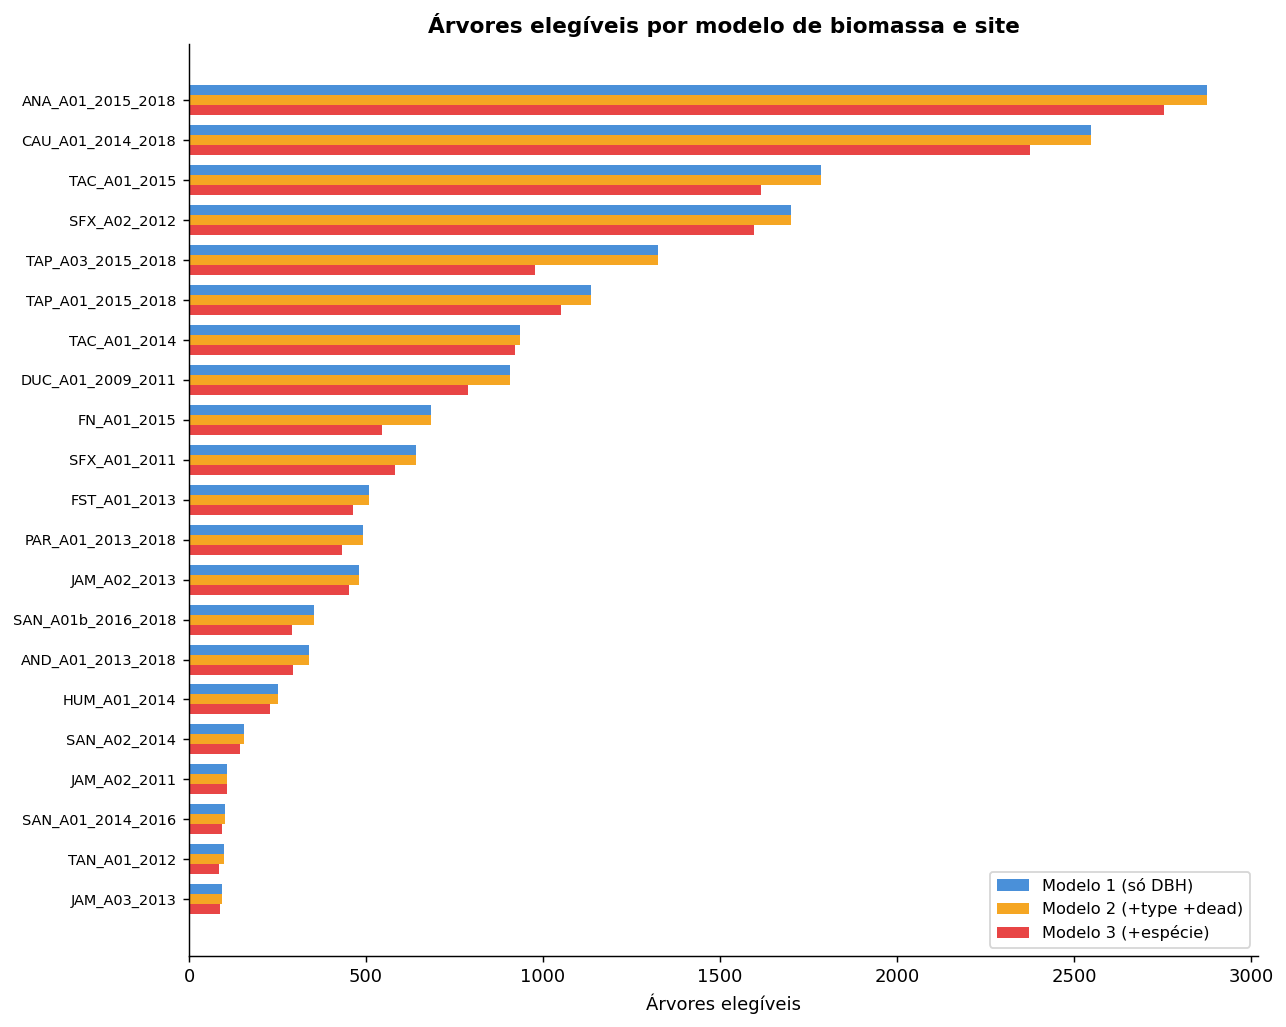

In [6]:
# Gráfico: elegibilidade por modelo, por site
ss = site_summary.sort_values("total", ascending=True).copy()
ss["site_short"] = ss["site"].str.replace("_inventory_plots|_inventory", "", regex=True)

fig, ax = plt.subplots(figsize=(10, 8))
y = np.arange(len(ss))
h = 0.25

ax.barh(y + h,   ss["m1"], height=h, color="#4a90d9", label="Modelo 1 (só DBH)")
ax.barh(y,       ss["m2"], height=h, color="#f5a623", label="Modelo 2 (+type +dead)")
ax.barh(y - h,   ss["m3"], height=h, color="#e84545", label="Modelo 3 (+espécie)")

ax.set_yticks(y)
ax.set_yticklabels(ss["site_short"], fontsize=8)
ax.set_xlabel("Árvores elegíveis")
ax.set_title("Árvores elegíveis por modelo de biomassa e site", fontweight="bold")
ax.legend(loc="lower right", fontsize=9)
plt.tight_layout()
plt.show()

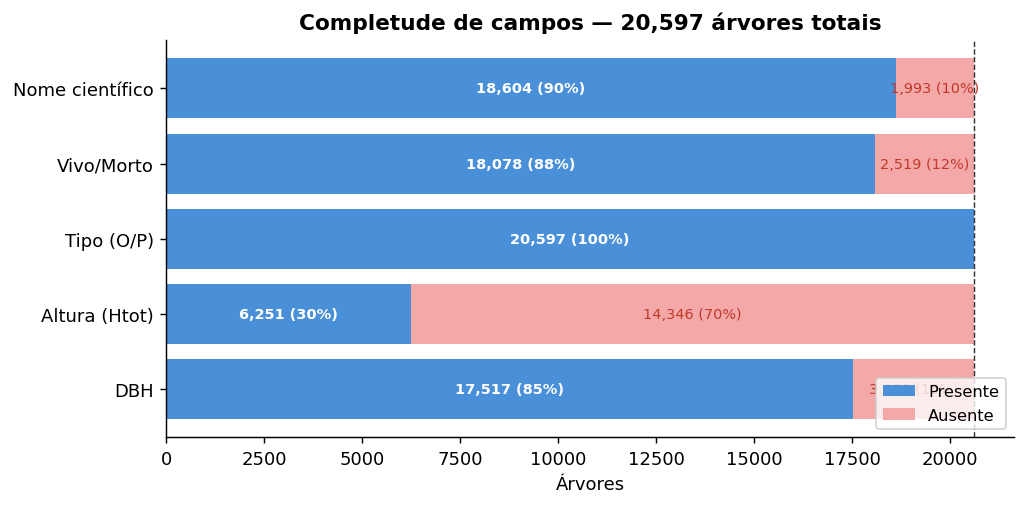

In [7]:
# Gráfico: campos ausentes globalmente
campos = {
    "DBH":              trees["ok_dbh"].sum(),
    "Altura (Htot)":    trees["ok_htot"].sum(),
    "Tipo (O/P)": trees["ok_type"].sum(),
    "Vivo/Morto":       trees["ok_dead"].sum(),
    "Nome científico":  trees["ok_sci"].sum(),
}
n_total = len(trees)

fig, ax = plt.subplots(figsize=(8, 4))
labels = list(campos.keys())
present = list(campos.values())
absent  = [n_total - v for v in present]

bars_p = ax.barh(labels, present, color="#4a90d9", label="Presente")
bars_a = ax.barh(labels, absent, left=present, color="#f5a8a8", label="Ausente")

for bar, v in zip(bars_p, present):
    pct = 100 * v / n_total
    ax.text(v / 2, bar.get_y() + bar.get_height() / 2,
            f"{v:,} ({pct:.0f}%)", va="center", ha="center", fontsize=8, color="white", fontweight="bold")

for bar, v in zip(bars_a, absent):
    if v > 0:
        pct = 100 * v / n_total
        x = present[absent.index(v)] + v / 2
        ax.text(x, bar.get_y() + bar.get_height() / 2,
                f"{v:,} ({pct:.0f}%)", va="center", ha="center", fontsize=8, color="#c0392b")

ax.set_xlabel("Árvores")
ax.axvline(n_total, color="#333", linestyle="--", linewidth=0.8)
ax.set_title(f"Completude de campos — {n_total:,} árvores totais", fontweight="bold")
ax.legend(loc="lower right", fontsize=9)
ax.set_xlim(0, n_total * 1.05)
plt.tight_layout()
plt.show()

In [8]:
# Resumo final dos modelos
print("=== Resumo de elegibilidade por modelo ===")
print(f"{'Total de árvores:':<45} {len(trees):>7,}")
print()
for m, label, desc in [
    ("modelo_1", "Modelo 1", "ignora espécie, palmeira e vivo/morto"),
    ("modelo_2", "Modelo 2", "ignora espécie, usa palmeira e vivo/morto"),
    ("modelo_3", "Modelo 3", "usa espécie, palmeira e vivo/morto"),
]:
    n = trees[m].sum()
    print(f"{label} — {desc}")
    print(f"  {'Elegíveis:':<43} {n:>7,}  ({100*n/len(trees):.0f}%)")
    print(f"  {'Excluídas:':<43} {len(trees)-n:>7,}  ({100*(len(trees)-n)/len(trees):.0f}%)")
    print()

print("Nota: altura (Htot) ausente na maioria das árvores — Chave 2014 será")
print("aplicado na versão sem altura (equação com índice ambiental E)")
n_htot = trees["ok_htot"].sum()
print(f"      Árvores com Htot: {n_htot:,} ({100*n_htot/len(trees):.0f}%)")

=== Resumo de elegibilidade por modelo ===
Total de árvores:                              20,597

Modelo 1 — ignora espécie, palmeira e vivo/morto
  Elegíveis:                                   17,517  (85%)
  Excluídas:                                    3,080  (15%)

Modelo 2 — ignora espécie, usa palmeira e vivo/morto
  Elegíveis:                                   17,517  (85%)
  Excluídas:                                    3,080  (15%)

Modelo 3 — usa espécie, palmeira e vivo/morto
  Elegíveis:                                   15,884  (77%)
  Excluídas:                                    4,713  (23%)

Nota: altura (Htot) ausente na maioria das árvores — Chave 2014 será
aplicado na versão sem altura (equação com índice ambiental E)
      Árvores com Htot: 6,251 (30%)
